<img src='http://drive.google.com/uc?export=view&id=1UAsSD6z0wK4UJjjzBhDEIlSZnELLmeeb' width="200">

#Project 3: Building a Predictive Model to Answer Research Questions
##Titanic Survivability

Submitted by:<br>
Michael Morgan, 30301873,michael.morgan@ucalgary.ca <br>
Sundeep Parmar, 30301836, sundeep.parmar@ucalgary.ca <br>
Yu Ling Wong, 30297454, yuling.wong@ucalgary.ca <br>


## <font color='lightblue'>1. Ask a question </font>

-------
**Question of Interest**

-------

We were interested in building a model to see if we could predict the survivability of passengers on the Titanic based on certain predictors. Initially, we hypothesized that sex, class and age would be the main predictors of survival, but perhaps fare and location of the cabin on the ship would also be contributors. Ideally, we wanted to create a model that clearly predicted what factors helped lead to survival.


-------
**Data Sources**

-------


<a href= "https://github.com/Sundeep-Parmar-UC/Data601-Project3/blob/main/titanic.csv"> Dataset Link </a>


The dataset for the Titanic passengers comes from the Data Science Dojo public access github. This data set was declared as public, non-commercial use on their website. The data is generally used for their classroom instructions. <br>

Complete accuracy of every passenger was not verified and there are no comments on the validity for the data set from Data Science Dojo. Our own sample check of several of the data entries confirmed this is an accurate account of individuals from the Titantic passenger ship. <br>

-------
**The Purpose of the Model**

-------

The ML problem we are facing is prediction of a target variable based on predictor variables. As such, the classification models of decision tree and then a random forest were built to predict the survival outcome.

## <font color='lightblue'>2. Data understanding, exploration, and visualization </font>

-------
**Data Overview**

-------

The data was imported from a github source and it was presented in 12 columns. The dataset that we will be using contains information of each passengers for the Titanic cruise ship such as : <br>
- PassengerId - Index for each passenger <br>
- Survived - survival status (0-not survived, 1-survived) <br>
- Pclass - ticket class <br>
- Name - passenger name <br>
- Sex - passenger sex <br>
- Age - passenger age <br>
- SibSp - count of sibling/spouse <br>
- Parch - count of parent/child <br>
- Ticket - ticket number <br>
- Fare - ticket fare (in £) <br>
- Cabin - cabin number <br>
- Embarked - boarding location <br><br>

Some pre-processing work was performed on the data so it is more relevent to our topic of investigation. One example of such work is by dropping irrelevant columns. We found the passenger names and ticket numbers were unique to each individual/row. These columns were dropped as they did not contain identifiers to assist in decision making/clustering. The sibling/spouse and parent/child information columns were also dropped as the majority of the family member data was recorded as separate entries within the dataset. We made an assumption that the information for each family member was fully captured in the dataset. <br>
<br>
A cabin class (deck level A,B,C...) and ship position columns (front, middle, or back of the ship) were created  to help identify and categorize the location of each passenger’s cabin. This will be helpful for our analysis on the survival rate based on cabin locations and deck levels.
Below shows the illustrations of the Titanic's floorplan and cross-section showing the deck levels and cabin numbers. <br>
(Diagrams source:
[Cross-section](https://en.wikipedia.org/wiki/First-class_facilities_of_the_Titanic),
[Deck level](https://www.encyclopedia-titanica.org/titanic-deckplans/b-deck.html))
<br><br>
**Cross-section of ship illustrating deck levels**

<img src="https://raw.githubusercontent.com/ylwong98/Data601-Project3/main/Titanic_cutaway_floorlevel_diagram.png" width="400">
<br><br>

**Front of the deck**

<img src="https://raw.githubusercontent.com/ylwong98/Data601-Project3/main/Titanic_B_front.png" width="1400">
<br><br>

**Back of the deck**

<img src="https://raw.githubusercontent.com/ylwong98/Data601-Project3/main/Titanic_B_back.png" width="1400">

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
#!pip install dtreeviz
import dtreeviz

titanicDF = pd.read_csv("https://raw.githubusercontent.com/Sundeep-Parmar-UC/Data601-Project3/refs/heads/main/titanic.csv")

In [ ]:
#create new coloumn called CabinClass, fill it with the first letter from the Cabin column,  if null then set as X
titanicDF['CabinClass'] = titanicDF['Cabin'].str[0].fillna("X")
titanicDF['CabinClass'].groupby(titanicDF['CabinClass']).count()

#create temporaryCabin dataframe with cabin information
temporaryCabinData = titanicDF[['CabinClass','Cabin']].copy() # Create a copy to avoid SettingWithCopyWarning

#walk through each row of temp data and generate cabin number based on removing first letter of cabin
temporaryCabinData['CabinNumber'] = ""
for index, row in temporaryCabinData.iterrows():
  if pd.notna(row['Cabin']) and len(row['Cabin']) > 1: # Check if Cabin is not NaN and has more than one character
      if row['Cabin'][1].isdigit(): # Check if the second character is a digit
        temporaryCabinData.loc[index, 'CabinNumber'] = row['Cabin'][1:3] # Use .loc for assignment
      else:
        temporaryCabinData.loc[index, 'CabinNumber'] = "00"
  else:
    temporaryCabinData.loc[index, 'CabinNumber'] = "00"

#convert CabinNumber to int
temporaryCabinData.CabinNumber = temporaryCabinData.CabinNumber.astype(int)

#return max cabin number by CabinClass group
DictionaryofCabinHighLow = temporaryCabinData.groupby('CabinClass').CabinNumber.max()

#create new temporaryCabinData column ShipPosition
temporaryCabinData['ShipPosition'] = ""

#walk through each row of temporaryCabinData,
#if CabinNumber is lower then half from group DictionaryofCabinHighLow then set Position as Front
for index, row in temporaryCabinData.iterrows():
  maxValue = DictionaryofCabinHighLow[row['CabinClass']]
  #if row cabinNumer is 0 then set to middle
  if row['CabinNumber'] == 0:
    temporaryCabinData.loc[index, 'ShipPosition'] = "Middle"
  elif (row['CabinNumber'] < maxValue/2):
    temporaryCabinData.loc[index, 'ShipPosition'] = "Front"
  else:
    temporaryCabinData.loc[index, 'ShipPosition'] = "Back"

#take temporaryCabinData ShipPosition and add it titanticDF
titanicDF['ShipPosition'] = temporaryCabinData['ShipPosition']

#drop coloumns that are unique to each passenger and not for clustering
titanicDF = titanicDF.drop(['Name'],axis=1) #drop name column
titanicDF = titanicDF.drop(['Ticket'],axis=1) #drop ticket column
titanicDF = titanicDF.drop(['SibSp'],axis=1) #drop Sibling/Spouse column
titanicDF = titanicDF.drop(['Parch'],axis=1) #drop Parent/Child column
titanicDF = titanicDF.drop(['Cabin'],axis=1) #drop cabin column

The section below shows the number of variables and name of each variables we are dealing with after some minor pre-processing steps.

In [ ]:
#check variable names of dataframe after pre-processing
titanicDF.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked',
       'CabinClass', 'ShipPosition'],
      dtype='object')

In [ ]:
#get total number of column variables
len(titanicDF.columns)

9

In [ ]:
titanicDF.head(3)

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,CabinClass,ShipPosition
0,1,0,3,male,22.0,7.2500,S,X,Middle
1,2,1,1,female,38.0,71.2833,C,C,Back
2,3,1,3,female,26.0,7.9250,S,X,Middle


Plots below demonstrated the distributions and correlations between the variables of interest namely survival status, sex, and ticket class.

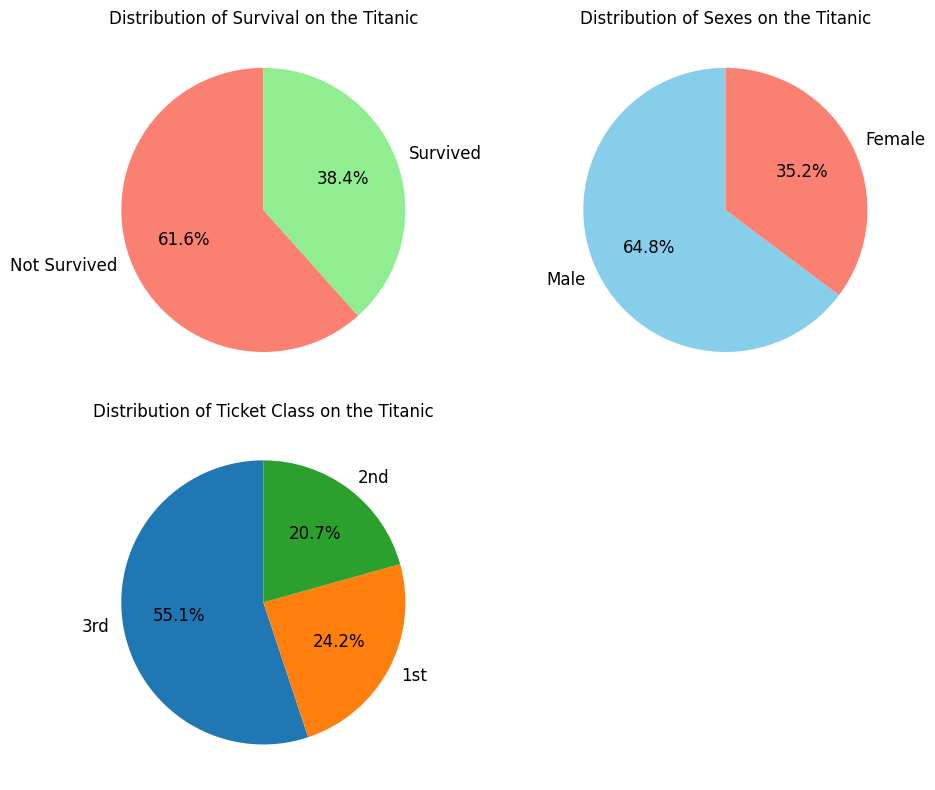

In [ ]:
#Create a figure and a set of subplots for pie charts
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

#Plot 1: Survival Status
survival_counts = titanicDF['Survived'].value_counts()
axes[0, 0].pie(survival_counts, labels=['Not Survived', 'Survived'], autopct='%1.1f%%', startangle=90, colors=['salmon', 'lightgreen'], textprops={'fontsize': 12})
axes[0, 0].set_title('Distribution of Survival on the Titanic')

#Plot 2: Distribution of Sexes
sex_counts = titanicDF['Sex'].value_counts()
axes[0, 1].pie(sex_counts, labels=['Male', 'Female'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'], textprops={'fontsize': 12})
axes[0, 1].set_title('Distribution of Sexes on the Titanic')

#Plot 3: Distribution of Ticket Class (Pclass)
class_counts = titanicDF['Pclass'].value_counts()
axes[1, 0].pie(class_counts, labels=['3rd', '1st','2nd'], autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1, 0].set_title('Distribution of Ticket Class on the Titanic')

fig.delaxes(axes[1, 1]) #hide unused subplot
plt.tight_layout()

Based on the plotted pie charts, it can be observed that approximately **38.4%** of passengers **survived** the shipwreck, while **61.6% did not**, highlighting the high fatality rate of the disaster. This helped set the stage for exploring factors that influenced survival rate. <br><br>
The passenger population was found to be predominantly male (64.8%), with females making up 35.2%. This chart offers a clear view of the passenger demographics aboard the ship, which is useful for comparing survival rates by sex. <br><br>
It was also found that over half of the passengers traveled in 3rd class (55.1%), followed by 1st class (24.2%) and 2nd class (20.7%). This distribution reflects the socioeconomic diversity aboard the Titanic, which is also useful for further comparison on the survival rates by ticket class. <br>



/tmp/ipython-input-876043171.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipython-input-876043171.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipython-input-876043171.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
/tmp/ipython-input-876043171.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipython-input-876043171.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and se

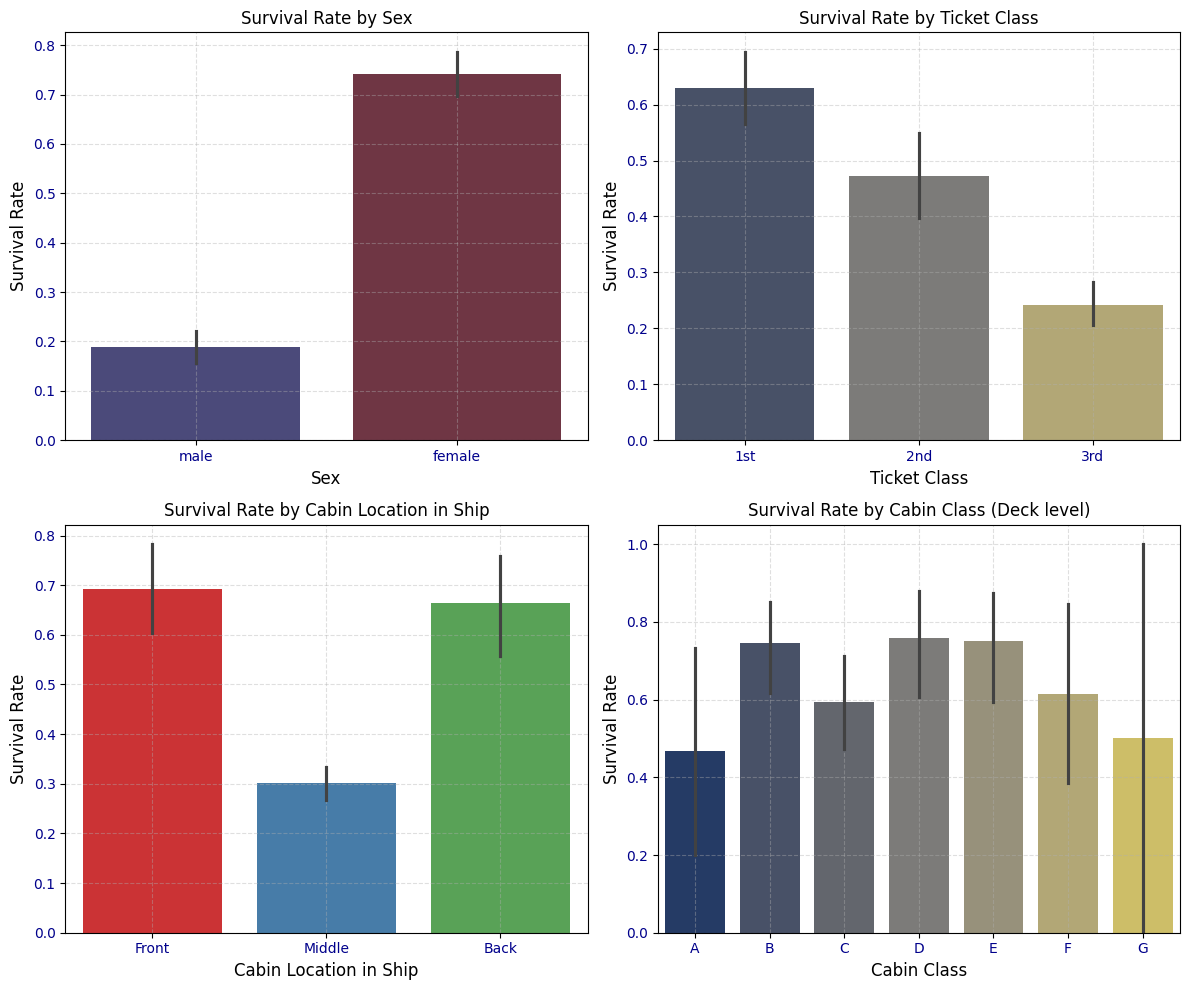

In [ ]:
#Create a figure and a set of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Plot 1: Survival Rate by Sex
sns.barplot(x='Sex', y='Survived', data=titanicDF, ax=axes[0,0], palette='icefire',  legend=False)
axes[0,0].set_title('Survival Rate by Sex', fontsize=12)
axes[0,0].set_ylabel('Survival Rate', fontsize=12)
axes[0,0].set_xlabel('Sex', fontsize=12)
axes[0,0].tick_params(labelsize=10, labelcolor='darkblue')
axes[0,0].grid(True, linestyle='--', alpha=0.4)

#Plot 2: Survival Rate by Ticket Class
sns.barplot(x='Pclass', y='Survived', data=titanicDF, ax=axes[0,1], palette='cividis',  legend=False)
axes[0,1].set_title('Survival Rate by Ticket Class', fontsize=12)
axes[0,1].set_ylabel('Survival Rate', fontsize=12)
axes[0,1].set_xlabel('Ticket Class', fontsize=12)
axes[0,1].set_xticklabels(['1st', '2nd', '3rd'])
axes[0,1].tick_params(labelsize=10, labelcolor='darkblue')
axes[0,1].grid(True, linestyle='--', alpha=0.4)

#Plot 3: Survival Rate by Cabin Location in Ship
sns.barplot(x='ShipPosition', y='Survived', data=titanicDF, ax=axes[1,0], palette='Set1',  order=['Front', 'Middle', 'Back'], legend=False)
axes[1,0].set_title('Survival Rate by Cabin Location in Ship', fontsize=12)
axes[1,0].set_ylabel('Survival Rate', fontsize=12)
axes[1,0].set_xlabel('Cabin Location in Ship', fontsize=12)
axes[1,0].tick_params(labelsize=10, labelcolor='darkblue')
axes[1,0].grid(True, linestyle='--', alpha=0.4)

#Plot 4: Survival Rate by Cabin Class (Deck level)
sns.barplot(x='CabinClass', y='Survived', data=titanicDF[~titanicDF['CabinClass'].isin(['T', 'X'])], ax=axes[1,1], palette='cividis',  order=['A','B','C','D','E','F','G'], legend=False)
axes[1,1].set_title('Survival Rate by Cabin Class (Deck level)', fontsize=12)
axes[1,1].set_ylabel('Survival Rate', fontsize=12)
axes[1,1].set_xlabel('Cabin Class', fontsize=12)
axes[1,1].tick_params(labelsize=10, labelcolor='darkblue')
axes[1,1].grid(True, linestyle='--', alpha=0.4)

#fig.delaxes(axes[1, 1]) #hide unused subplot
plt.tight_layout()

The barplots above illustrated the survival rate of passengers by **sex**, **ticket class**, **cabin location**, and **cabin class**.<br><br>
Females had a survival rate of around 75%, while males were closer to 19%. This sharp contrast highlights a strong gender-based difference in survival outcomes, suggesting that women may have been prioritized during evacuation.<br><br>
Passengers in 1st class had the highest survival rate (just over 62%), followed by 2nd class (around 48%) and 3rd class (around 25%). The trend shows that higher ticket class was associated with better chances of survival, indicating possible unequal access to lifeboats or evacuation routes.<br><br>

Passengers at the front and back of the ship had a relatively higher survival rate, while those in the middle had the lowest. This pattern might reflect how evacuation routes or lifeboat access varied by location. <br><br>

Survival rates vary widely across cabin classes. We hypothesized that passengers who has a cabin at the higher floors (from A, B, C so on) would expect a higher survival rate that the lower floors. The results were not showing as expected, maybe due to a large quantity of incomplete data affecting the results.<br>

/tmp/ipython-input-25484107.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



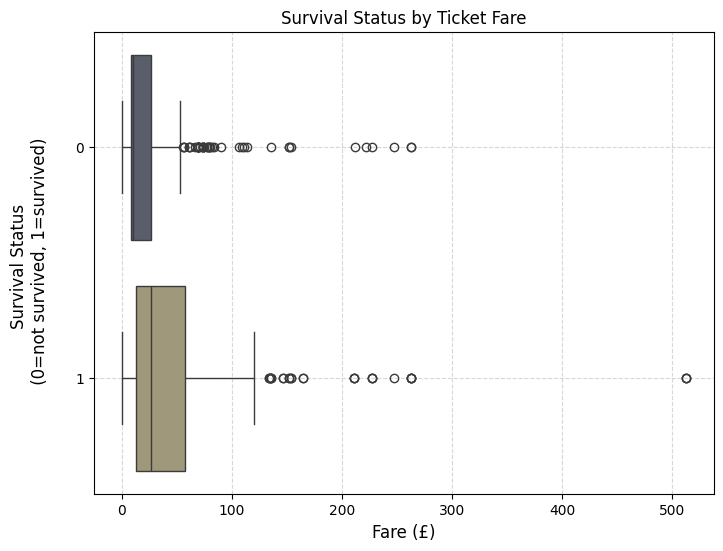

In [ ]:
#plot survival status based on ticket fare (Fare)
titanicDF['Survived'] = titanicDF['Survived'].astype('category')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Fare', y='Survived', data=titanicDF, palette='cividis')
plt.ylabel('Survival Status \n (0=not survived, 1=survived)\n', fontsize=12)
plt.xlabel('Fare (£)', fontsize=12)
plt.title('Survival Status by Ticket Fare')
plt.grid(True, linestyle='--', alpha=0.5)

The above box plot comparing survival status and ticket fare demonstrated a clear trend: passengers who survived generally paid higher fares than those who did not. Survivors have a noticeably higher median fare, and their distribution includes more high-fare outliers, suggesting that wealthier individuals may have had better access to lifeboats or safer areas of the ship.<br><br>
The spread of the data also indicates that fare amounts varied widely among survivors, while non-survivors tended to pay lower fares overall. This visual supports the idea that socioeconomic status played a role in survival outcomes during the Titanic disaster.<br>

/tmp/ipython-input-3303588329.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



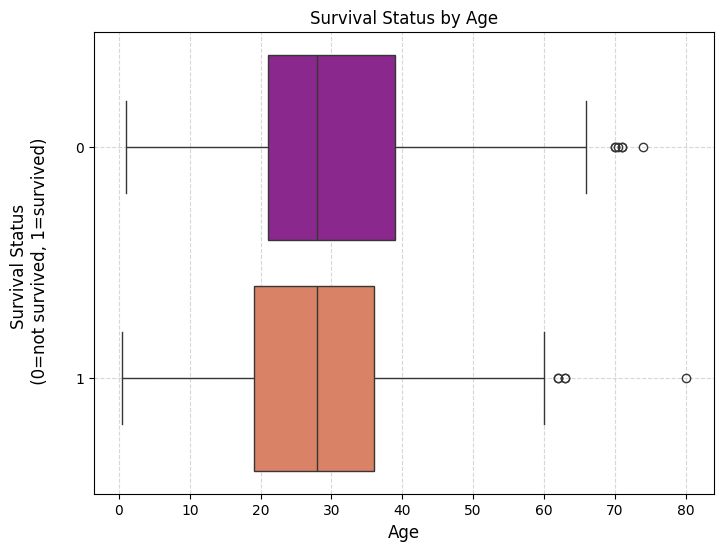

In [ ]:
#plot survival status based on age
titanicDF['Survived'] = titanicDF['Survived'].astype('category')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Age', y='Survived', data=titanicDF, palette='plasma')
plt.ylabel('Survival Status \n (0=not survived, 1=survived)\n', fontsize=12)
plt.xlabel('Age', fontsize=12)
plt.title('Survival Status by Age')
plt.grid(True, linestyle='--', alpha=0.5)

The above box plot compares the age distribution of passengers who survived versus those who didn’t. Survivors tend to be slightly younger on average, with a tighter age range and fewer older outliers. Non-survivors show a wider spread in age, including more older individuals. Overall, age appears to have had some influence on survival, though the overlap suggests it wasn’t the only factor at play.

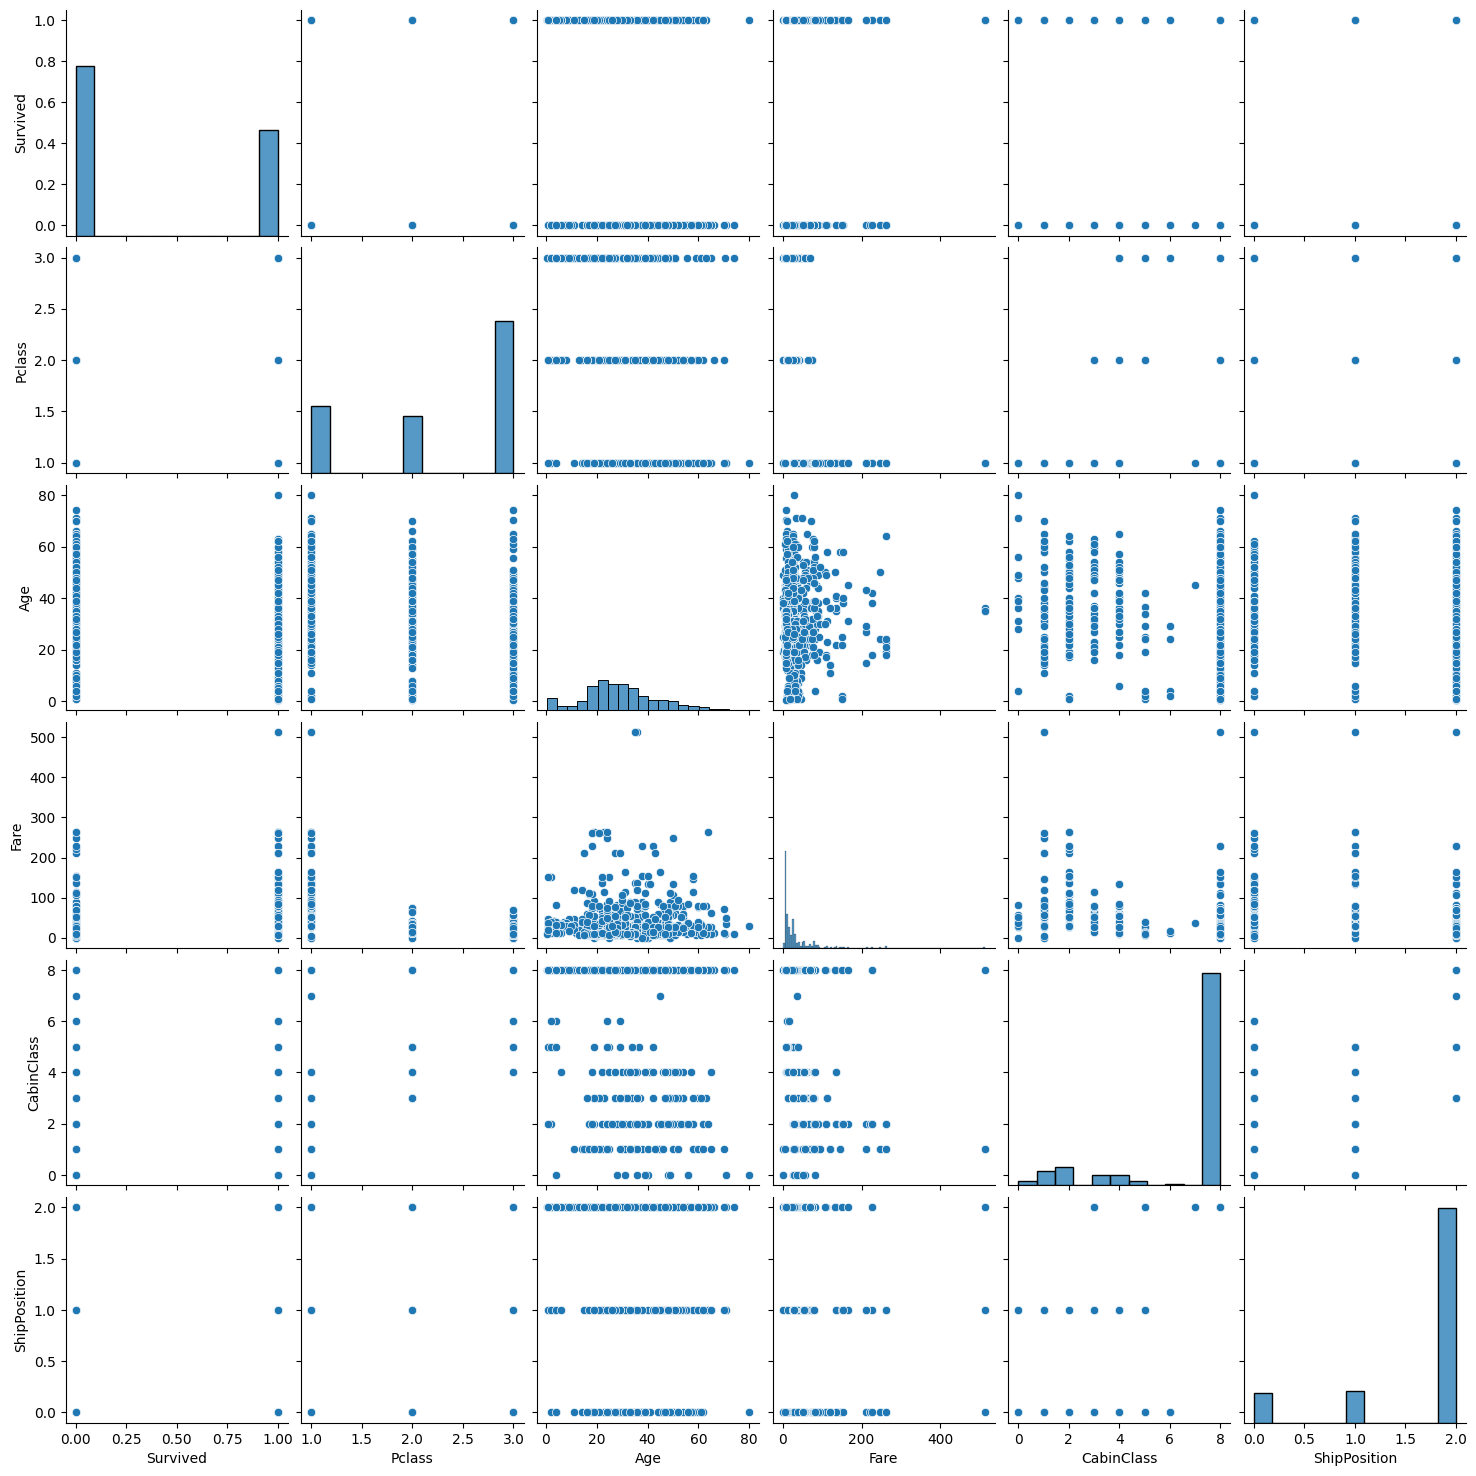

In [ ]:
#Heat Maps through correlation
TitanicPairs = titanicDF[["Survived","Pclass",'Age',"Fare","CabinClass",'ShipPosition']].copy()

#convert CabinClass,ShipPostion to numeric from Catergorical
TitanicPairs['ShipPosition'] = pd.Categorical(TitanicPairs['ShipPosition']).codes
TitanicPairs['CabinClass'] = pd.Categorical(TitanicPairs['CabinClass']).codes

#draw Correlation Matrix
sns.pairplot(TitanicPairs)

*Please see this visual, attached in the submission.

<Axes: >

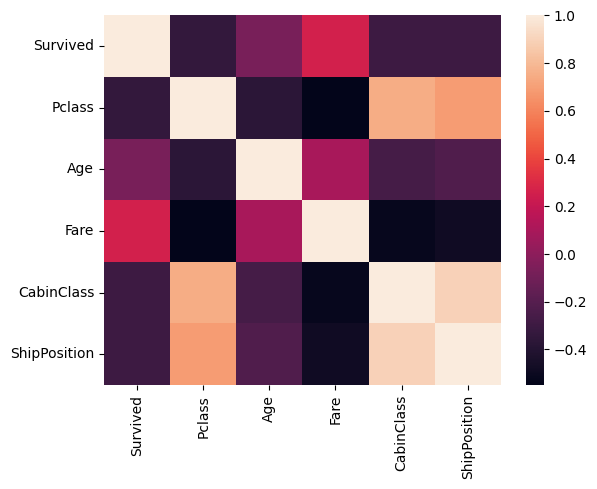

In [ ]:
#run a correlation on all combinations of variables in Chesspairs
corrmat = TitanicPairs.corr()
#plot the results as a heat map
sns.heatmap(corrmat, square=False)

*Please see this visual, attached in the submission.

We examined the data and identified six factors that may have generally contributed to the passenger’s fate. The factors:  Survived, Passenger class, Passenger Age, Fare Paid, Cabin Class, Cabin Ship Position.
Once a paired plot was created for correlation, we received some interesting results. The only diagram that was could be considered a scatterplot was Age vs. Fare Paid. However, this plot and all others do not present any correlation (i.e. r = 0).  <br> <br>
This result of no correlation is surprising, however, understandable because the data values were primarily 2 or 3 values.  Passenger Class is 1,2,3; Cabin Class is A, B, C, D, E, F, G. <br> <br>
Subsequently, the heat map attempted to colour-code the correlation values but also produced unreliable results.
This bolsters our decision to use the following decision tree and random forest models to investigate further.

## <font color='lightblue'>3. Data wrangling and preprocessing </font>

In preparation for building our model, we setup our dataset in the following steps:

1.   Identified Categorical Columns to make decisions
2.   Pivoted and created dummy columns to translate those categorical columns
3.   Filled in all remain NA values (not entirely necessary as data was cleaned in previous sections)

After pre-processing, we can then use the same pre-processed data for both models.

In [ ]:
#Identify categorical columns
categorical_cols = titanicDF.select_dtypes(include='object').columns
print("Categorical columns:", categorical_cols)

#Convert categorical columns to numerical using one-hot encoding
titanicDF_encoded = pd.get_dummies(titanicDF, columns=categorical_cols, dummy_na=False)

#Handle any remaining missing values (should only be from original numerical columns with NaNs)
#In this case, we'll fill remaining NaNs with 0, but a more sophisticated imputation might be needed depending on the data.
titanicDF_encoded = titanicDF_encoded.fillna(0)

#Verify that there are no missing values and display the first few rows of the processed DataFrame
print("\nMissing values after processing:")
print(titanicDF_encoded.isnull().sum().sum())
display(titanicDF_encoded.head())

Categorical columns: Index(['Sex', 'Embarked', 'CabinClass', 'ShipPosition'], dtype='object')

Missing values after processing:
0


,PassengerId,Survived,Pclass,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,...,CabinClass_C,CabinClass_D,CabinClass_E,CabinClass_F,CabinClass_G,CabinClass_T,CabinClass_X,ShipPosition_Back,ShipPosition_Front,ShipPosition_Middle
0,1,0,3,22.0,7.2500,False,True,False,False,True,...,False,False,False,False,False,False,True,False,False,True
1,2,1,1,38.0,71.2833,True,False,True,False,False,...,True,False,False,False,False,False,False,True,False,False
2,3,1,3,26.0,7.9250,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
3,4,1,1,35.0,53.1000,True,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
4,5,0,3,35.0,8.0500,False,True,False,False,True,...,False,False,False,False,False,False,True,False,False,True


Split data for Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split

#Define features (X) and target variable (y)
X = titanicDF_encoded.drop('Survived', axis=1)
y = titanicDF_encoded['Survived']

#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Print the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (712, 21)
Shape of X_test: (179, 21)
Shape of y_train: (712,)
Shape of y_test: (179,)


## <font color='lightblue'>4. Build and test a model</font>



**Building the model**

### Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

#Instantiate the DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

#Train the model
classifier_res = decision_tree_model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

#Make predictions on the test set
y_pred = decision_tree_model.predict(X_test)

**Model Performance**

In [ ]:
#Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


#Print the metrics
print(f"Accuracy (tree): {accuracy:.4f}")
print(f"Precision (tree): {precision:.4f}")
print(f"Recall (tree): {recall:.4f}")

Accuracy (tree): 0.7821
Precision (tree): 0.7778
Recall (tree): 0.6622


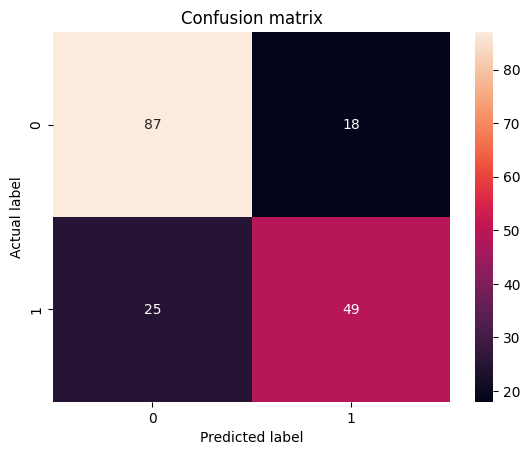

In [ ]:
#create confusion matrix for y_pred decision tree
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

The decision tree model achieved an accuracy of approximately 75% on the test set. This means that the model correctly predicted the survival status for about 75% of the passengers in the test set.

The precision of 73% indicates that when the model predicts a passenger will survive, it is correct about 73% of the time. The recall of 66% suggests that the model identifies about 66% of the passengers who actually survived.

The confusion matrix shows the breakdown of correct and incorrect predictions. The top-left cell represents true negatives (correctly predicted not survived), the top-right are false positives (incorrectly predicted survived), the bottom-left are false negatives (incorrectly predicted not survived), and the bottom-right are true positives (correctly predicted survived).

Let's explore hyperparameters for tuning the model. First, maxdepth.

In [ ]:
#split the data again into validation as well
X_hyper_train, X_hyper_val, y_hyper_train, y_hyper_val = train_test_split(X_train, y_train, test_size=0.20)

In [ ]:
#build a function the takes max depth as input and outputs a accuracy score.
def fit_decision_tree(maxDep):

  #1. build the algorithm
  classifier = DecisionTreeClassifier(max_depth=maxDep)

  #2. Fit the algorithm
  classifier_res= classifier.fit(X_hyper_train, y_hyper_train)

  #3. Make predictions
  y_pred = classifier.predict(X_hyper_val)

  #4. Meausure the accuracy
  accuracy_measured = sk.metrics.accuracy_score(y_hyper_val, y_pred)

  return accuracy_measured

In [ ]:
fit_decision_tree(maxDep=4)

0.7622377622377622

In [ ]:
acc_scores = []
for i in range(1,10):
  acc_s = fit_decision_tree(i)
  acc_scores.append(acc_s)

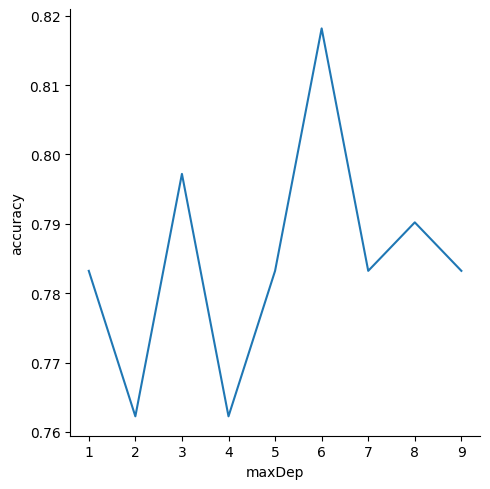

In [ ]:
#create a dataframe
df_plot_maxDep = pd.DataFrame({'accuracy':acc_scores, 'maxDep':range(1,10)})

#make a plot
sns.relplot(data=df_plot_maxDep, x='maxDep',y='accuracy', kind='line')

The optimal max depth appears to be around 5 most consistently. So we used this in our model above.

Now we test min_samples_split.

In [ ]:
#split the data again
X_hyper_train, X_hyper_val, y_hyper_train, y_hyper_val = train_test_split(X_train, y_train, test_size=0.20)

In [ ]:
#build a function the takes max depth as input and outputs a accuracy score.
def fit_decision_tree(minsamples):

  #1. build the algorithm
  classifier = DecisionTreeClassifier(min_samples_split=minsamples)

  #2. Fit the algorithm
  classifier_res= classifier.fit(X_hyper_train, y_hyper_train)

  #3. Make predictions
  y_pred = classifier.predict(X_hyper_val)

  #4. Meausure the accuracy
  accuracy_measured = sk.metrics.accuracy_score(y_hyper_val, y_pred)

  return accuracy_measured

In [ ]:
fit_decision_tree(minsamples=4)

0.6783216783216783

In [ ]:
acc_scores = []
for i in range(2,11): # Start from 2 as min_samples_split must be at least 2
  acc_s = fit_decision_tree(minsamples=i)
  acc_scores.append(acc_s)

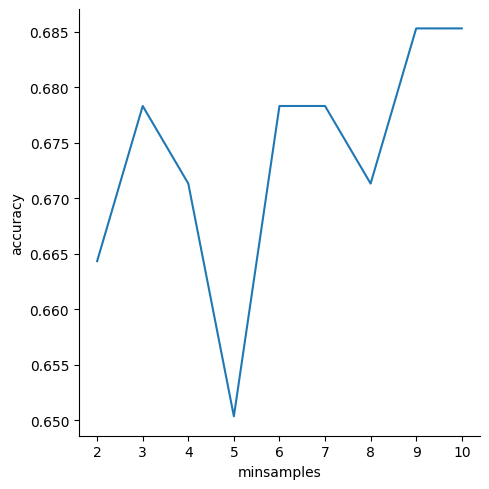

In [ ]:
#create a dataframe
df_plot_minsamples = pd.DataFrame({'accuracy':acc_scores, 'minsamples':range(2,11)}) # Update range to match the loop

#make a plot
sns.relplot(data=df_plot_minsamples, x='minsamples',y='accuracy', kind='line')

There doesn't appear to be a clear winner here. The results were not consistent and the difference was usually just a few accuracy percentage points, so we will not tune according to min_sample_split.

Let's try to build an optimized decision tree with maxdepth = 5

In [ ]:
from sklearn.tree import DecisionTreeClassifier

optimal_max_depth = 5 #5 seemed to be the optimal depth

# Instantiate the DecisionTreeClassifier
decision_tree_model_opt = DecisionTreeClassifier(max_depth=optimal_max_depth)

# Train the model
classifier_res = decision_tree_model_opt.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred = decision_tree_model_opt.predict(X_test)

In [ ]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


# Print the metrics
print(f"Accuracy (tree_tuned): {accuracy:.4f}")
print(f"Precision (tree_tuned): {precision:.4f}")
print(f"Recall (tree_tuned): {recall:.4f}")

Accuracy (tree_tuned): 0.7821
Precision (tree_tuned): 0.7778
Recall (tree_tuned): 0.6622


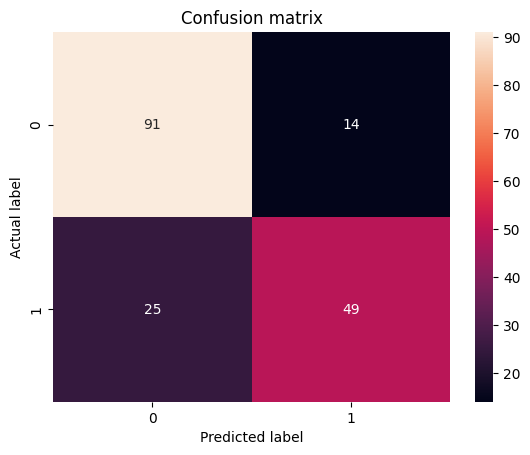

In [ ]:
#create confusion matrix for y_pred decision tree
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

The **tuned decision tree model** now shows an approximate **accuracy of 78%, precision of 77%, and a recall of 66%**, which has a slight improvement than the original model with an approximate accuracy of 75%, precision of 73%, and a recall of 66%.


Now let's look at the new dtreeviz. It's much easier to look at with fewer branches.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


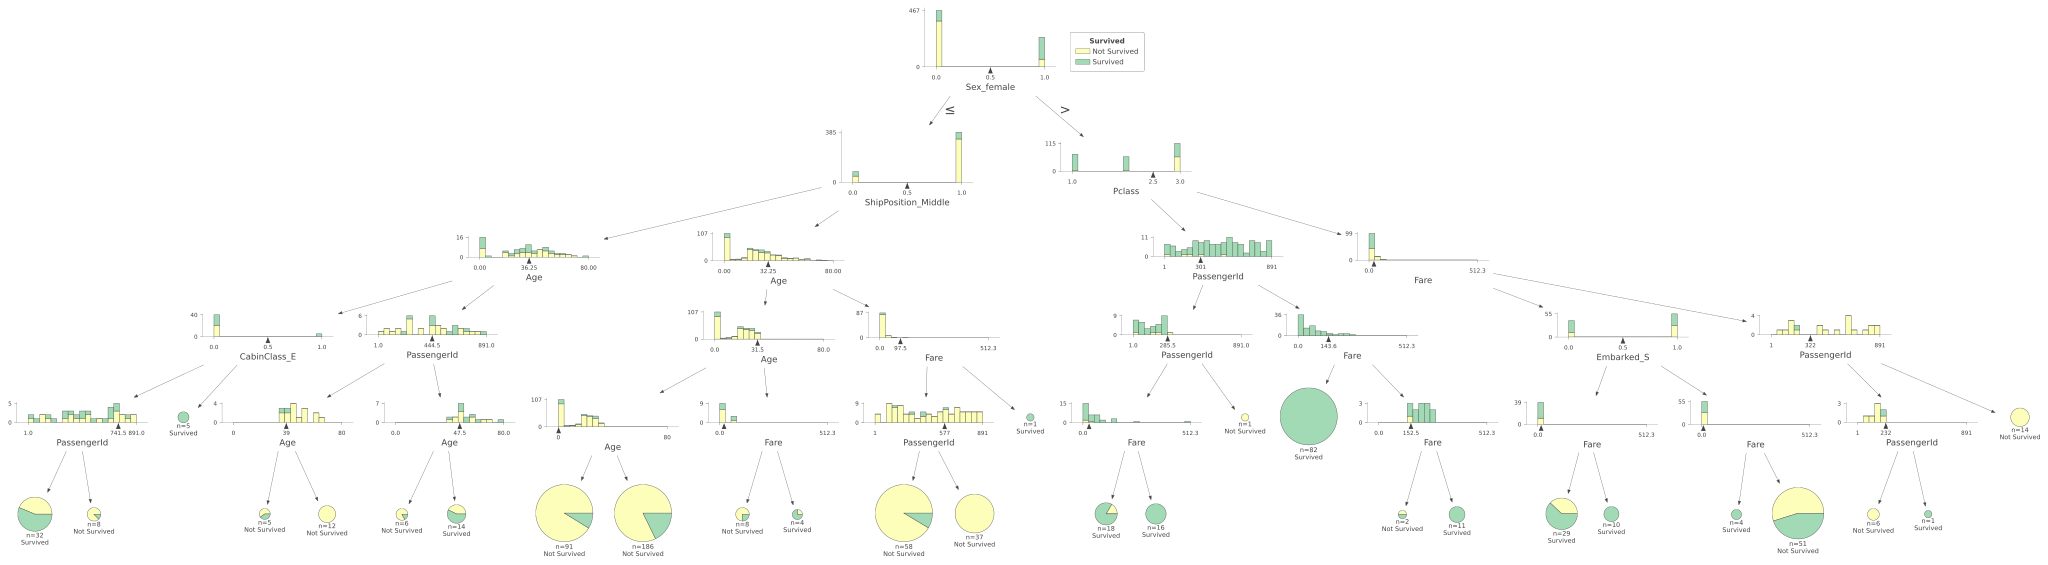

In [ ]:
#build the figure
viz = dtreeviz.model(classifier_res, X_train, y_train,
                target_name="Survived",
                feature_names=X_train.columns.to_list(),
                class_names={0:'Not Survived', 1:'Survived'} # Corrected class_names
                )

#take a look
viz.view(fontname="DejaVu Sans")

*Please see this visual, attached in the submission.

### Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#1. Build the model
forest_classifier = RandomForestClassifier(n_estimators=1000, bootstrap=True, max_features=0.8,max_samples=0.8)

#2. Fit the model to the data
forest_classifier.fit(X_train, y_train)

RandomForestClassifier(max_features=0.8, max_samples=0.8, n_estimators=1000)

In [ ]:
#predictions from the forest model
y_forest_pred = forest_classifier.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix
cm_forest = confusion_matrix(y_test, y_forest_pred)
print(cm_forest)


[[94 11]
 [25 49]]


Text(50.722222222222214, 0.5, 'True label')

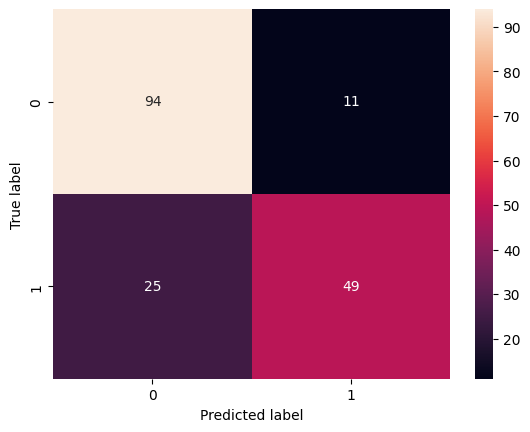

In [ ]:
#more visual approach
sns.heatmap(cm_forest, annot=True)
plt.xlabel('Predicted label')
plt.ylabel('True label')

In [ ]:
#Accuracy if we always predicted the most common value?
titanicDF.Survived.value_counts()
titanicDF.Survived.value_counts()[0]/(titanicDF.Survived.value_counts()[0]+titanicDF.Survived.value_counts()[1])

np.float64(0.6161616161616161)

In [ ]:
print('Accuracy (forest): {:.2f}'.format(sk.metrics.accuracy_score(y_test, y_forest_pred)))
print('Precision (forest): {:.2f}'.format(sk.metrics.precision_score(y_test, y_forest_pred)))
print('Recall (forest): {:.2f}'.format(sk.metrics.recall_score(y_test, y_forest_pred)))


Accuracy (forest): 0.80
Precision (forest): 0.82
Recall (forest): 0.66


Now we look into tuning the model using many hyperparameters

In [ ]:
from sklearn.model_selection import GridSearchCV

#define what parameters and what values to vary
parameters = {'max_features': [0.5,0.7,0.9,1.0],
              'n_estimators':list(range(50,200,50)),
              'max_samples':[0.5,0.7,0.9,0.99] }

#build the grid search algorithm
grid_search = GridSearchCV(RandomForestClassifier(), parameters, cv=5, scoring='accuracy') #strattified cross validation when traget is binary or multiclass

#Use training data to perform the nfold cross validation
grid_search.fit(X_train, y_train)

#find the best hyperparameters
print(grid_search.best_params_)
grid_search.best_score_

{'max_features': 0.9, 'max_samples': 0.5, 'n_estimators': 50}


np.float64(0.8159755737220525)

Trying the results from the grid search to build an optimized model...

In [ ]:
#1. build an optimized model
forest_classifier_opt = RandomForestClassifier(n_estimators=50,max_samples=0.5, max_features=0.5)

#2. Fit the model to the data
forest_classifier_opt.fit(X_train, y_train)

#3. make predictions
y_forest_pred_opt = forest_classifier_opt.predict(X_test)

#Measure accuracy
print('Accuracy (forest_tuned): {:.2f}'.format(sk.metrics.accuracy_score(y_test, y_forest_pred_opt)))
print('Precision (forest_tuned): {:.2f}'.format(sk.metrics.precision_score(y_test, y_forest_pred_opt)))
print('Recall (forest_tuned): {:.2f}'.format(sk.metrics.recall_score(y_test, y_forest_pred_opt)))

Accuracy (forest_tuned): 0.81
Precision (forest_tuned): 0.81
Recall (forest_tuned): 0.70


Text(50.722222222222214, 0.5, 'True label')

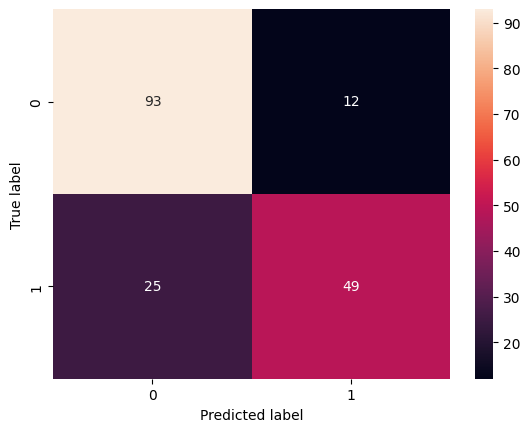

In [ ]:
#calculate a confusion matrix
cm_forest_opt = confusion_matrix(y_test, y_forest_pred_opt)

#Plot the confusion matrix
sns.heatmap(cm_forest_opt, annot=True)
plt.xlabel('Predicted label')
plt.ylabel('True label')

Below shows the comparison on the approximate performance of the ransom forest model before and after tuning.
<br><br>
<hr>

**Original model:**

Accuracy: 0.80, <br>
Precision: 0.82, <br>
Recall: 0.66
<hr>

**Tuned model:**

Accuracy: 0.79, <br>
Precision : 0.80, <br>
Recall : 0.66

<hr>

The tuning doesn't seem to have made a difference in the performance of the random forrest model.

## <font color='lightblue'>5. Interpret your model</font>

We ran the permutation of importance test on the decision tree and the random forest model. <br>
First, the decision tree:

In [ ]:
from sklearn.inspection import permutation_importance

#use permutation importance
perm_result = permutation_importance(decision_tree_model_opt, X=X_test, y=y_test, scoring='accuracy', n_repeats=30)

#place values into a dataframe
tree_importances = pd.DataFrame({'variable':X_test.columns,'impo':perm_result.importances_mean.round(4), "sd":perm_result.importances_std.round(4)})

#sort the dataframe
tree_importances.sort_values(by='impo', ascending=False)

,variable,impo,sd
4,Sex_female,0.1510,0.0298
20,ShipPosition_Middle,0.0689,0.0200
1,Pclass,0.0680,0.0164
8,Embarked_S,0.0199,0.0115
2,Age,0.0184,0.0075
3,Fare,0.0156,0.0136
12,CabinClass_D,0.0000,0.0000
6,Embarked_C,0.0000,0.0000
5,Sex_male,0.0000,0.0000
9,CabinClass_A,0.0000,0.0000


<Axes: xlabel='impo', ylabel='variable'>

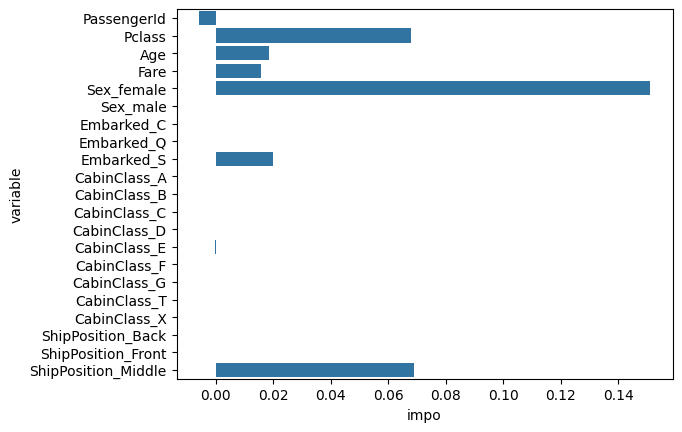

In [ ]:
#plot the importance (switch axis to display labels better?)
sns.barplot(data=tree_importances, y='variable',x='impo')

*Please see this visual, attached in the submission.

Now let's look at what important predictors we have for the random forest. We'll see if they are the same.

In [ ]:
from sklearn.inspection import permutation_importance

#use permutation importance
perm_result = permutation_importance(forest_classifier_opt, X=X_test, y=y_test, scoring='accuracy', n_repeats=30)

#place values into a dataframe
forest_importances = pd.DataFrame({'variable':X_test.columns,'impo':perm_result.importances_mean.round(4), "sd":perm_result.importances_std.round(4)})

#sort the dataframe
forest_importances.sort_values(by='impo', ascending=False)

,variable,impo,sd
4,Sex_female,0.0708,0.0190
1,Pclass,0.0561,0.0169
5,Sex_male,0.0385,0.0184
2,Age,0.0108,0.0146
13,CabinClass_E,0.0095,0.0036
8,Embarked_S,0.0058,0.0073
7,Embarked_Q,0.0052,0.0035
18,ShipPosition_Back,0.0039,0.0033
3,Fare,0.0006,0.0115
14,CabinClass_F,-0.0000,0.0014


<Axes: xlabel='impo', ylabel='variable'>

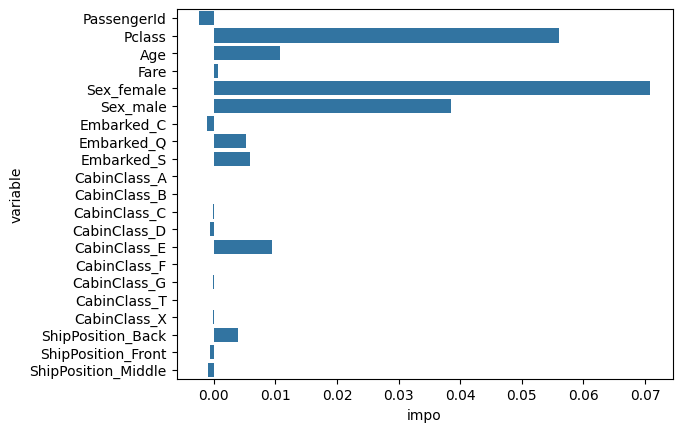

In [ ]:
#plot the importance (switch axis to display labels better?)
sns.barplot(data=forest_importances, y='variable',x='impo')

*Please see this visual, attached in the submission.

Based on the plotted importance graph for both models, it was found that,
<br><br>
for the *Decision Tree model* :
- **Sex_female**, **ShipPosition_Middle**, **Pclass** (ie. ticket class) were the top 3 important predictors, valued at approximately 15.1%, 6.9%, and 6.8% respectively.
- **PassengerId** was a negative importance predictor of the model, suggetsing it might be adding noise or irrelevant information to the model. Therefore, removing it might slightly improve the model's overall predictive performance.

for the *Random Forest model* :
- **Sex_female**, **Pclass**(ie. ticket class), **Sex_male** were the top 3 important predictors, valued at approximately 7.1%, 5.6%, and 3.9% respectively.
- A few variables such as **PassengerId**, **Embarked_C**, and **ShipPosition_Middle** were found to have a negative importance. Similar to the decision tree model, removing these features may help improve the overall performance.

## <font color='lightblue'>6. Answer your question</font>

**Model Comparisons**


After our attempt in Project 2 using the nursing data that didn't quite pan out for a predictive model, we were eager to find a dataset that could provide a clear and explainable LM model. Overall we were pleased with the results of the model using the Titanic dataset.
<br><br>

By comparing the two models (post-tuning performance), <br>
Decision tree = Accuracy: 78%, Precision: 77%, Recall: 66% <br>
Random forest = Accuracy: 79%, Precision: 80%, Recall: 66% <br><br>

The random forest demonstrated a slightly better result in terms of predictive performance. However, the decision tree has better explanability, where it provides a clear, visual representation of how decisions are made, making it easier to understand the influence of individual features.<br><br>

For predictive accuracy, the random forest is generally preferable. It leverages multiple decision trees to reduce variance and capture complex patterns, making it more robust and reliable. However, interpretability is a priority, the decision tree is often the better choice. Its structure is transparent and easy to visualize, which makes it ideal for communicating how predictions are made.<br><br>

**What determined survivability?**

Our analysis demonstrated that sex and class were the strongest predictors of survival on the Titanic. These results are consistent with historical accounts. <br><br>

First-class passengers had a much higher chance of survival, while those in second and third class were far more likely to perish. Women were also more likely to survive than men, reflecting the “women and children first” evacuation policy followed during the disaster.<br><br>

We expected cabin location or deck level to be another important factor, since first-class cabins were typically on higher decks closer to lifeboats. However, our model did not find this to be a significant predictor. This is possibly due to incomplete or missing cabin number data.<br><br>

To contrast with the modern day, we likely would not observe such a difference between class and gender. And modern safety standards and advancements would ensure that survivability would be different.<br><br>

In summary, our model reinforced what’s long been understood about the Titanic tragedy. Social class and gender were the key factors influencing survival.